In [0]:
from pyspark.sql.functions import col, sum as _sum
import matplotlib.pyplot as plt
import pandas as pd

appointments_data = [
    (1001,"Hyderabad","Cardiology","Apollo",1500,"Completed"),
    (1002,"Bangalore","Neurology","Yashoda",2200,"Completed"),
    (1003,"Mumbai","Dermatology","Care",900,"Pending"),
    (1004,"Delhi","Orthopedics","Max",2500,"Completed"),
    (1005,"Chennai","Pediatrics","Apollo",1200,"Cancelled"),
    (1006,"Hyderabad","Cardiology","Care",3000,"Completed"),
    (1007,"Bangalore","Dermatology","Apollo",1000,"Completed"),
    (1008,"Mumbai","Neurology","Max",2600,"Pending"),
    (1009,"Delhi","Cardiology","Yashoda",2800,"Completed"),
    (1010,"Chennai","Orthopedics","Care",2400,"Completed"),
    (1011,"Hyderabad","Pediatrics","Apollo",1100,"Completed"),
    (1012,"Bangalore","Cardiology","Max",3200,"Completed"),
    (1013,"Mumbai","Pediatrics","Yashoda",1300,"Cancelled"),
    (1014,"Delhi","Neurology","Apollo",2700,"Completed"),
    (1015,"Chennai","Dermatology","Care",950,"Pending")
]
columns = ["appointment_id","city","department","hospital","consultation_fee","status"]
df = spark.createDataFrame(appointments_data, columns)
pdf = df.toPandas()  

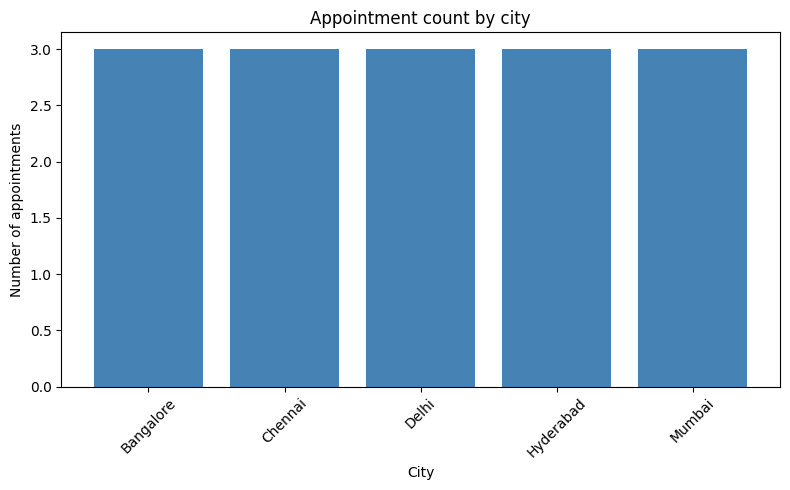

In [0]:
city_count = pdf.groupby("city")["appointment_id"].count().reset_index()
city_count.columns = ["city", "count"]

plt.figure(figsize=(8, 5))
plt.bar(city_count["city"], city_count["count"], color="steelblue")
plt.title("Appointment count by city")
plt.xlabel("City")
plt.ylabel("Number of appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

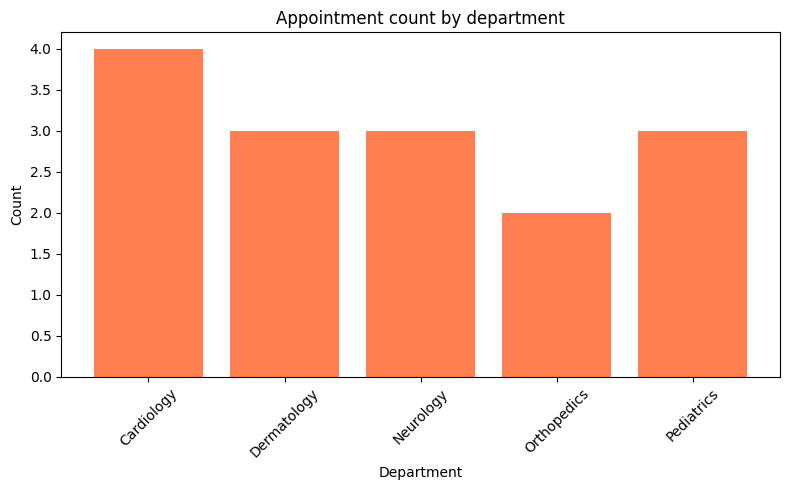

In [0]:
dept_count = pdf.groupby("department")["appointment_id"].count().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(dept_count["department"], dept_count["appointment_id"], color="coral")
plt.title("Appointment count by department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

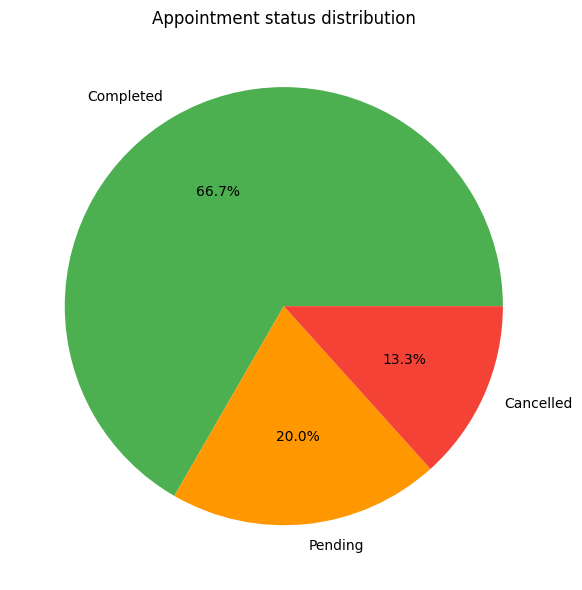

In [0]:
status_count = pdf["status"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(status_count, labels=status_count.index, autopct="%1.1f%%",
        colors=["#4CAF50", "#FF9800", "#F44336"])
plt.title("Appointment status distribution")
plt.tight_layout()
plt.show()

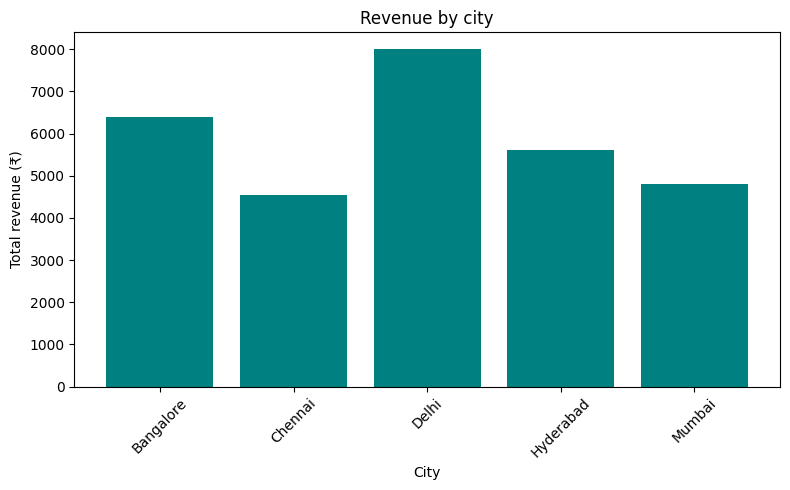

In [0]:
city_rev = pdf.groupby("city")["consultation_fee"].sum().reset_index()
city_rev.columns = ["city", "revenue"]
plt.figure(figsize=(8, 5))
plt.bar(city_rev["city"], city_rev["revenue"], color="teal")
plt.title("Revenue by city")
plt.xlabel("City")
plt.ylabel("Total revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

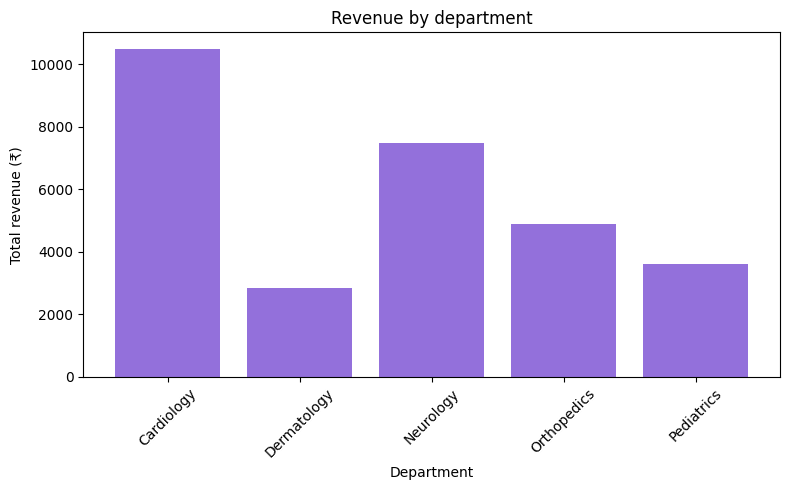

In [0]:
dept_rev = pdf.groupby("department")["consultation_fee"].sum().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(dept_rev["department"], dept_rev["consultation_fee"], color="mediumpurple")
plt.title("Revenue by department")
plt.xlabel("Department")
plt.ylabel("Total revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

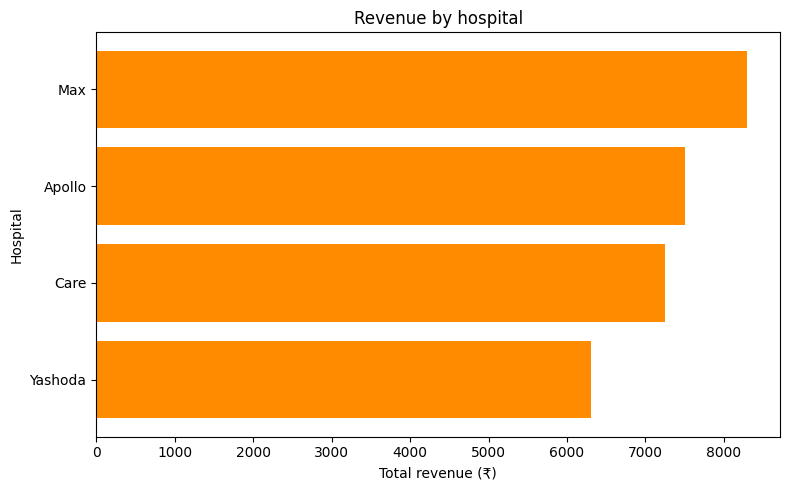

In [0]:
hosp_rev = pdf.groupby("hospital")["consultation_fee"].sum().sort_values()
plt.figure(figsize=(8, 5))
plt.barh(hosp_rev.index, hosp_rev.values, color="darkorange")
plt.title("Revenue by hospital")
plt.xlabel("Total revenue (₹)")
plt.ylabel("Hospital")
plt.tight_layout()
plt.show()

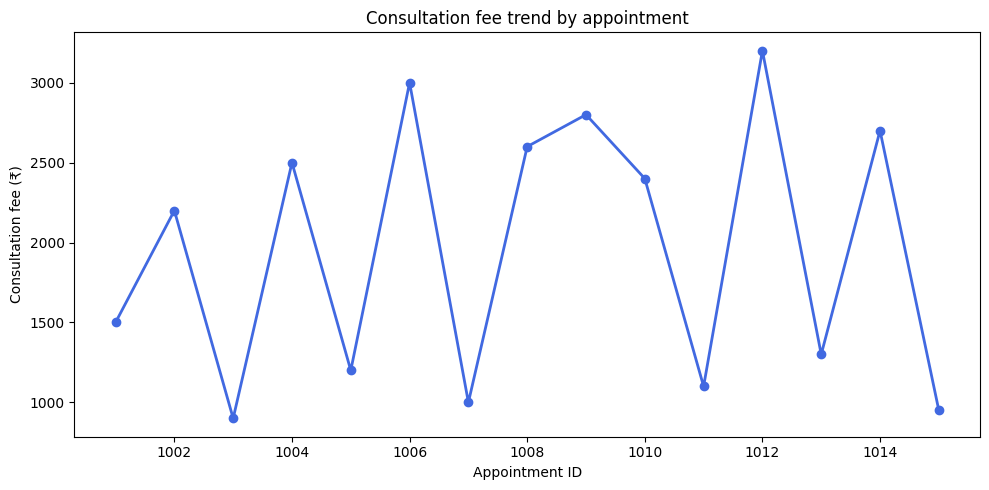

In [0]:
trend = pdf.sort_values("appointment_id")
plt.figure(figsize=(10, 5))
plt.plot(trend["appointment_id"], trend["consultation_fee"],
         marker="o", color="royalblue", linewidth=2)
plt.title("Consultation fee trend by appointment")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation fee (₹)")
plt.tight_layout()
plt.show()

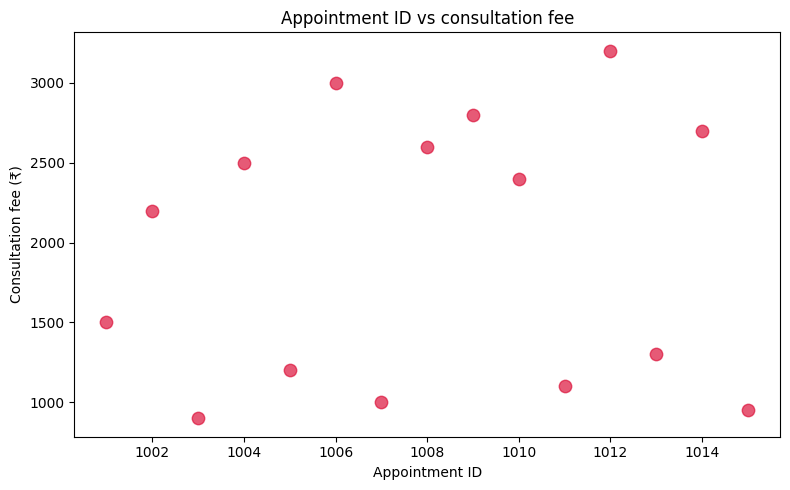

In [0]:
plt.figure(figsize=(8, 5))
plt.scatter(pdf["appointment_id"], pdf["consultation_fee"],
            color="crimson", s=80, alpha=0.7)
plt.title("Appointment ID vs consultation fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation fee (₹)")
plt.tight_layout()
plt.show()

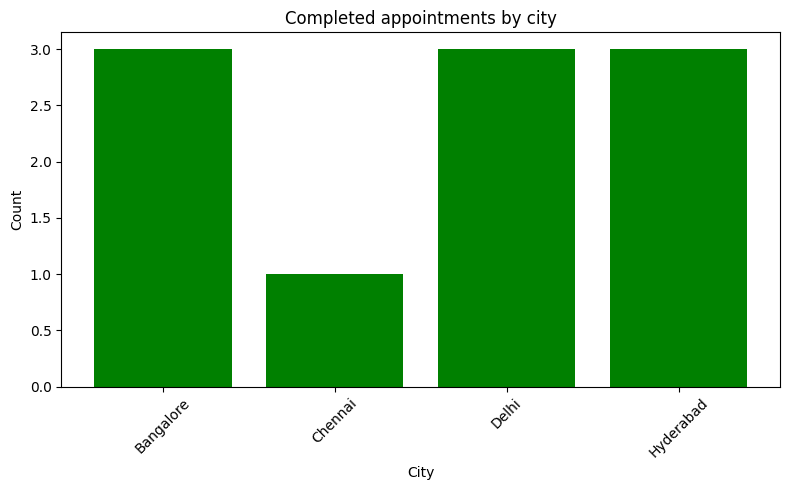

In [0]:
completed = pdf[pdf["status"] == "Completed"]
comp_city = completed.groupby("city")["appointment_id"].count().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(comp_city["city"], comp_city["appointment_id"], color="green")
plt.title("Completed appointments by city")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

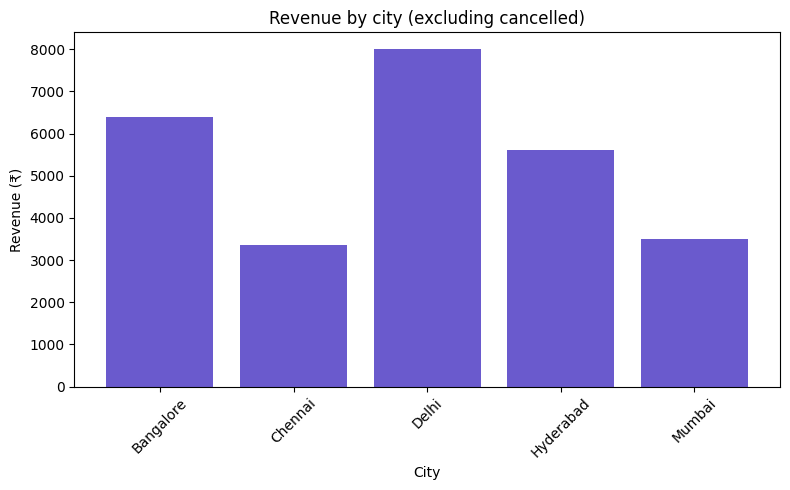

In [0]:
not_cancelled = pdf[pdf["status"] != "Cancelled"]
nc_city = not_cancelled.groupby("city")["consultation_fee"].sum().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(nc_city["city"], nc_city["consultation_fee"], color="slateblue")
plt.title("Revenue by city (excluding cancelled)")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

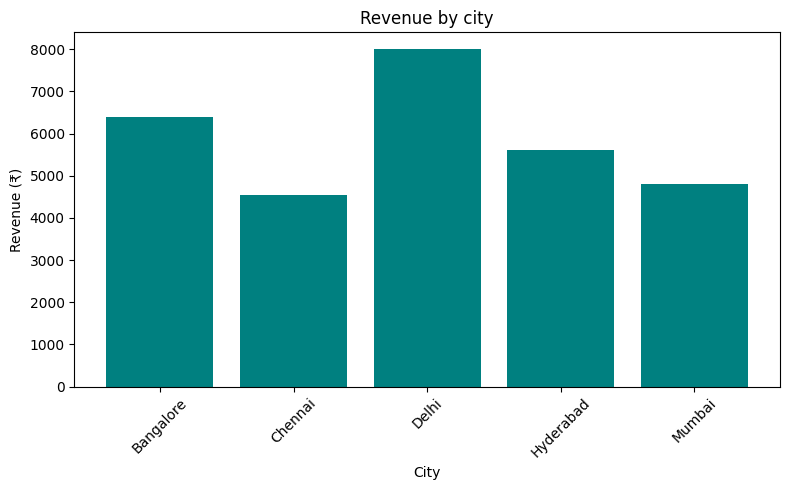

In [0]:
plt.figure(figsize=(8, 5))
plt.bar(city_rev["city"], city_rev["revenue"], color="teal")
plt.title("Revenue by city")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'My custom chart title')

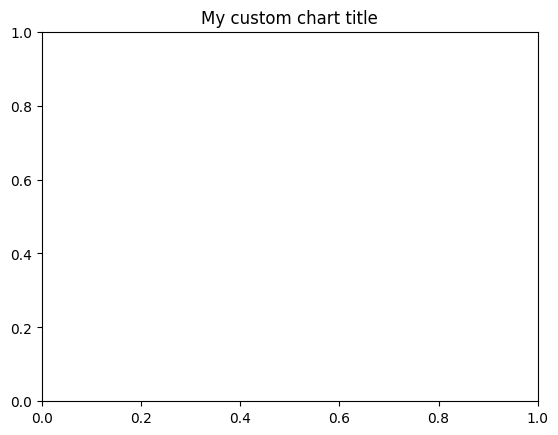

In [0]:
plt.title("My custom chart title")    

Text(0.5, 0, 'My x-axis label')

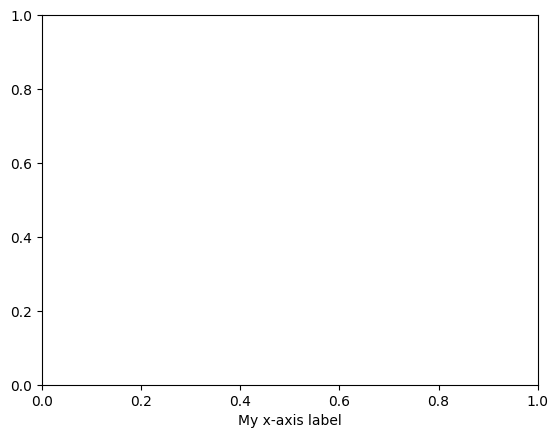

In [0]:
plt.xlabel("My x-axis label")

Text(0, 0.5, 'My y-axis label')

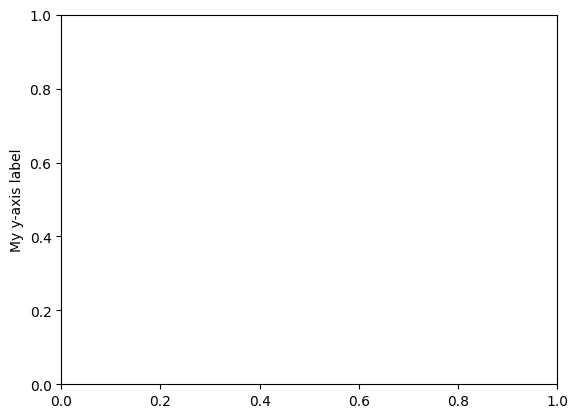

In [0]:
plt.ylabel("My y-axis label")

In [0]:
plt.figure(figsize=(12, 7))    

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

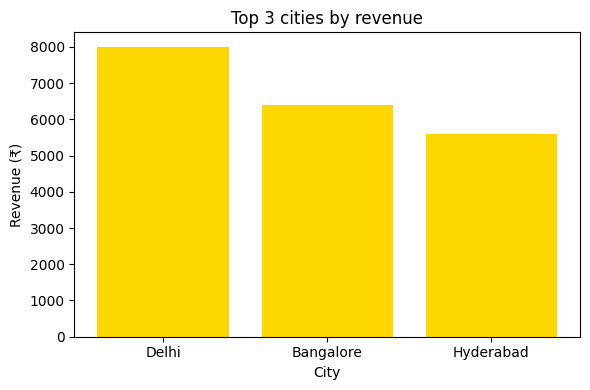

In [0]:
top3_cities = city_rev.sort_values("revenue", ascending=False).head(3)
plt.figure(figsize=(6, 4))
plt.bar(top3_cities["city"], top3_cities["revenue"], color="gold")
plt.title("Top 3 cities by revenue")
plt.xlabel("City")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()

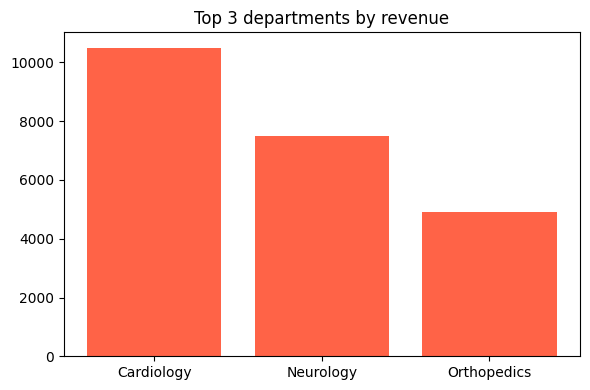

In [0]:
dept_rev_sorted = dept_rev.sort_values("consultation_fee", ascending=False).head(3)
plt.figure(figsize=(6, 4))
plt.bar(dept_rev_sorted["department"], dept_rev_sorted["consultation_fee"],
        color="tomato")
plt.title("Top 3 departments by revenue")
plt.tight_layout()
plt.show()

Lowest revenue hospital: Yashoda — ₹6300


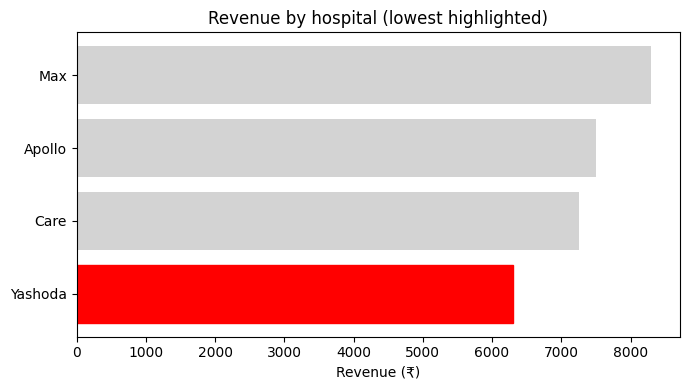

In [0]:
lowest = hosp_rev.idxmin()
print(f"Lowest revenue hospital: {lowest} — ₹{hosp_rev[lowest]}")
plt.figure(figsize=(7, 4))
bars = plt.barh(hosp_rev.index, hosp_rev.values, color="lightgray")
bars[list(hosp_rev.index).index(lowest)].set_color("red")   # highlight it
plt.title("Revenue by hospital (lowest highlighted)")
plt.xlabel("Revenue (₹)")
plt.tight_layout()
plt.show()

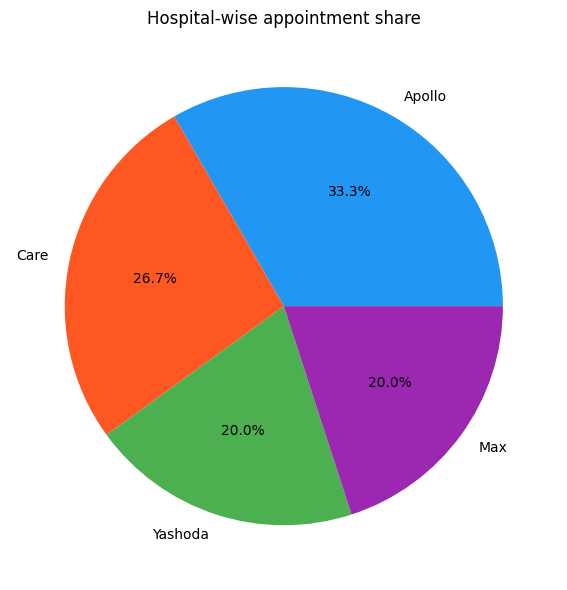

In [0]:
hosp_count = pdf["hospital"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(hosp_count, labels=hosp_count.index, autopct="%1.1f%%",
        colors=["#2196F3","#FF5722","#4CAF50","#9C27B0"])
plt.title("Hospital-wise appointment share")
plt.tight_layout()
plt.show()

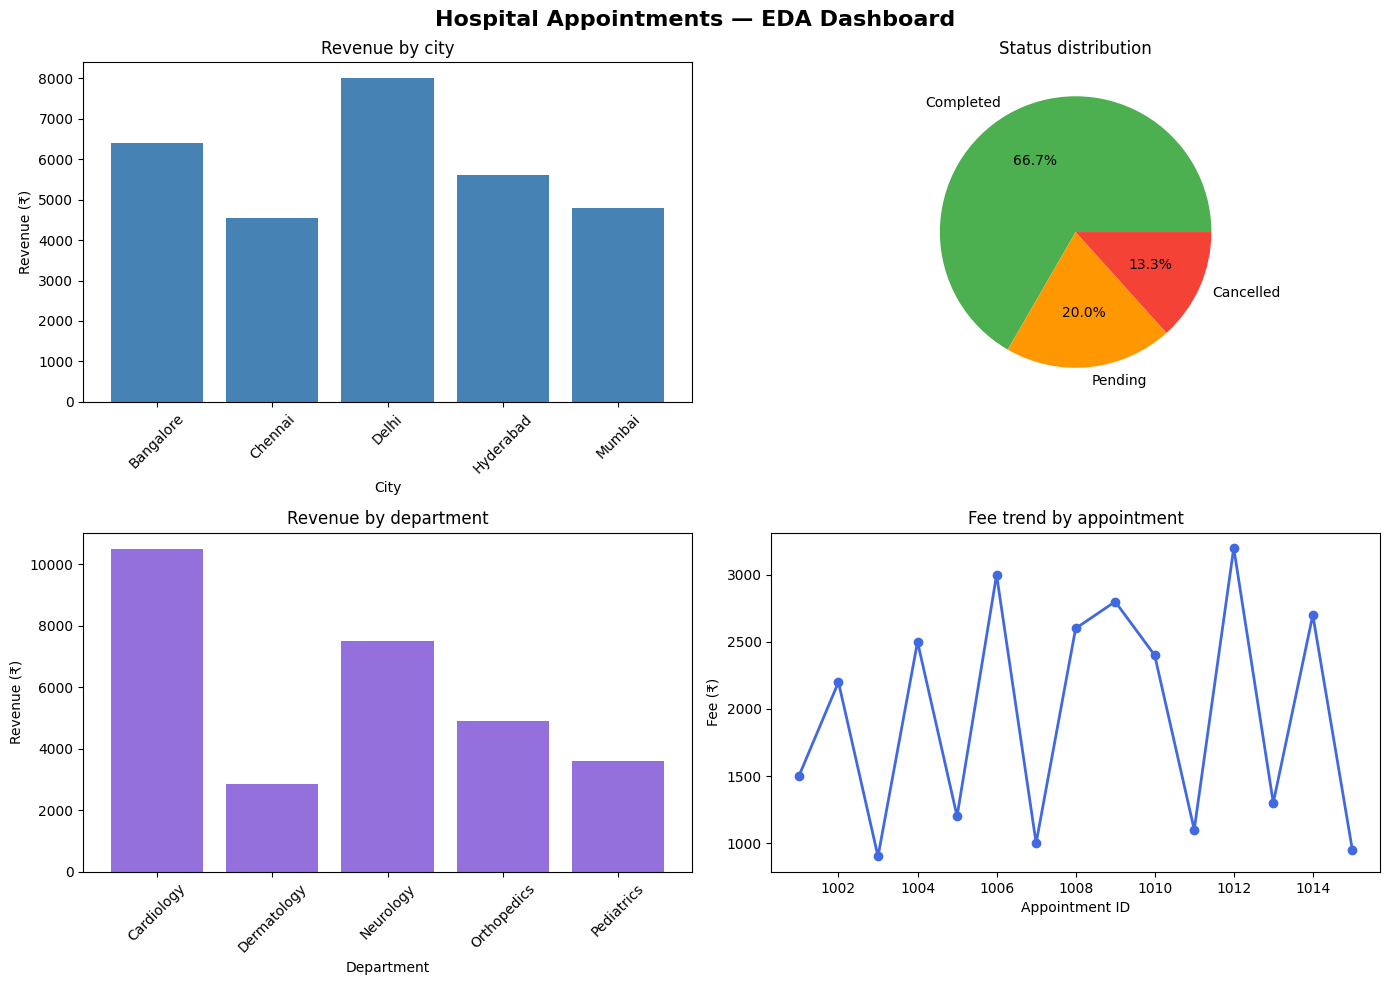

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Hospital Appointments — EDA Dashboard", fontsize=16, fontweight="bold")

# Chart 1 — Revenue by city
city_rev_s = pdf.groupby("city")["consultation_fee"].sum()
axes[0,0].bar(city_rev_s.index, city_rev_s.values, color="steelblue")
axes[0,0].set_title("Revenue by city")
axes[0,0].set_xlabel("City")
axes[0,0].set_ylabel("Revenue (₹)")
axes[0,0].tick_params(axis="x", rotation=45)

# Chart 2 — Status distribution (pie)
status_c = pdf["status"].value_counts()
axes[0,1].pie(status_c, labels=status_c.index, autopct="%1.1f%%",
              colors=["#4CAF50","#FF9800","#F44336"])
axes[0,1].set_title("Status distribution")

# Chart 3 — Revenue by department
dept_rev_s = pdf.groupby("department")["consultation_fee"].sum()
axes[1,0].bar(dept_rev_s.index, dept_rev_s.values, color="mediumpurple")
axes[1,0].set_title("Revenue by department")
axes[1,0].set_xlabel("Department")
axes[1,0].set_ylabel("Revenue (₹)")
axes[1,0].tick_params(axis="x", rotation=45)

# Chart 4 — Fee trend line
trend_s = pdf.sort_values("appointment_id")
axes[1,1].plot(trend_s["appointment_id"], trend_s["consultation_fee"],
               marker="o", color="royalblue", linewidth=2)
axes[1,1].set_title("Fee trend by appointment")
axes[1,1].set_xlabel("Appointment ID")
axes[1,1].set_ylabel("Fee (₹)")
plt.tight_layout()
plt.show()